In [2]:
#Tratamiento de datos

import numpy as np
import pandas as pd

#GRAFICOS
import matplotlib.pyplot as plt

#Preprocesado y modelo

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA



In [4]:

df = pd.DataFrame(
    np.array([
        [7, 6.5, 9.2, 8.6, 8],
        [7.5, 9.4, 7.3, 7, 7],
        [7.6, 9.2, 8, 8, 7.5],
        [5, 6.5, 6.5, 7, 9],
        [6, 6, 7.8, 8.9, 7.3],
        [7.8, 9.6, 7.7, 8, 6.5],
        [6.3, 6.4, 8.2, 9, 7.2],
        [7.9, 9.7, 7.5, 8, 6],
        [6, 6, 6.5, 5.5, 8.7],
        [6.8, 7.2, 8.7, 9, 7]
    ]),
    index=['Lucia', 'Pedro', 'Ines', 'Luis', 'Andres',
        'Ana', 'Carlos', 'Jose', 'Sonia', 'Maria'],
    columns=[ 'Matematicas', 'Ciencias', 'Español', 'Historia', 'EdFisica'])

df 

,Matematicas,Ciencias,Español,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,6.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
Maria,6.8,7.2,8.7,9.0,7.0


In [7]:
# Determinar el numero de renglones de la base de datos
index = df.index
renglones = len(index)
renglones

10

In [8]:
# Estandarización de las variables
df2 = StandardScaler().fit_transform(df)
df2

array([[ 0.23263076, -0.7529862 ,  1.78848525,  0.65792263,  0.65858084],
       [ 0.78651352,  1.14584856, -0.53899555, -0.84590053, -0.47690337],
       [ 0.89729007,  1.01489444,  0.31849737,  0.09398895,  0.09083874],
       [-1.98290027, -0.7529862 , -1.51898747, -0.84590053,  1.79406505],
       [-0.87513476, -1.0803715 ,  0.07349939,  0.93988948, -0.13625811],
       [ 1.11884317,  1.27680268, -0.0489996 ,  0.09398895, -1.04464547],
       [-0.5428051 , -0.81846326,  0.56349535,  1.03387842, -0.24980653],
       [ 1.22961972,  1.34227974, -0.29399757,  0.09398895, -1.61238758],
       [-0.87513476, -1.0803715 , -1.51898747, -2.25573474,  1.45341979],
       [ 0.01107766, -0.29464677,  1.1759903 ,  1.03387842, -0.47690337]])

In [9]:
# Calcular la matriz de correlaciones para la matriz transformada
A = (1/renglones) * np.dot(df2.T, df2)
A

array([[ 1.        ,  0.85407878,  0.38457424,  0.20719425, -0.78716269],
       [ 0.85407878,  1.        , -0.02005218, -0.02153942, -0.68772056],
       [ 0.38457424, -0.02005218,  1.        ,  0.82091619, -0.36554342],
       [ 0.20719425, -0.02153942,  0.82091619,  1.        , -0.50800132],
       [-0.78716269, -0.68772056, -0.36554342, -0.50800132,  1.        ]])

In [10]:
# Entrenamiento del modelo PCA con escalado de los datos
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df)

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

print("Eigenvalores:")
results = LA.eigvals(A)
print(results)

Eigenvalores:
[2.89324967 1.62865042 0.34659605 0.00889139 0.12261246]


In [11]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componente
[0.57864993 0.32573008 0.06931921 0.02452249 0.00177828]


In [12]:
# Cálculo de eigenvectores
print("Eigenvectores (por renglon):")
pd.DataFrame(data = modelo_pca.components_,
             columns = df.columns,
             index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

Eigenvectores (por renglon):


,Matematicas,Ciencias,Español,Historia,EdFisica
PC1,-0.526644,-0.424936,-0.359147,-0.352697,0.537302
PC2,-0.270496,-0.508072,0.562082,0.586490,0.093746
PC3,0.438201,0.040495,0.562276,-0.394180,0.578626
PC4,-0.261218,0.673627,-0.070086,0.446645,0.523056
PC5,-0.623878,0.325390,0.483747,-0.420433,-0.306794


In [13]:
# Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(proyecciones, index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones

,PC1,PC2,PC3,PC4,PC5
Lucia,-0.323063,1.772525,1.198801,-0.055015,-0.003633
Pedro,-0.665441,-1.638702,0.145476,-0.023065,0.123377
Ines,-1.002547,-0.515692,0.628888,0.516444,-0.142876
Luis,3.172095,-0.262782,-0.381960,0.677777,0.062504
Andres,0.488868,1.365402,-0.835236,-0.155792,-0.123367
Ana,-1.708633,-1.021700,-0.127077,0.066833,-0.025292
Carlos,-0.067586,1.462336,-0.506240,-0.117928,-0.013124
Jose,-2.011855,-1.275865,-0.542150,-0.197787,-0.017434
Sonia,3.042030,-1.254881,0.448829,-0.639999,-0.037885
Maria,-0.923869,1.369359,-0.029330,-0.071467,0.177730


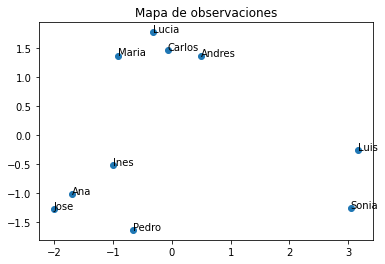

In [14]:
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]
z = df.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [16]:
componentes_2 = pd.DataFrame(data = modelo_pca.components_,
                             columns = df.columns,
                             index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
componentes_2 = componentes_2.iloc[0:2, :]
componentes_2 = componentes_2.T
componentes_2

,PC1,PC2
Matematicas,-0.526644,-0.270496
Ciencias,-0.424936,-0.508072
Español,-0.359147,0.562082
Historia,-0.352697,0.586490
EdFisica,0.537302,0.093746


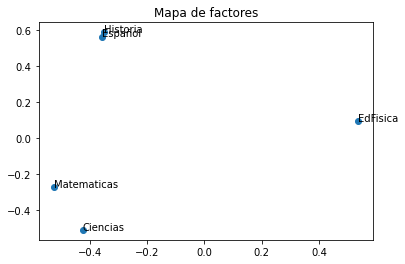

In [17]:
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [ ]:
#### ACP con IRIS


In [3]:
df = pd.read_csv("iris.csv")
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [5]:
# Estandarización de las variables
df2 = StandardScaler().fit_transform(df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']])
df2

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [6]:
# Calcular la matriz de correlaciones para la matriz transformada
renglones = df2.shape[0]
A = (1/renglones) * np.dot(df2.T, df2)
A

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [7]:
# Entrenamiento del modelo PCA con escalado de los datos
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']])

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

print("Eigenvalores:")
results = LA.eigvals(A)
print(results)

Eigenvalores:
[2.91849782 0.91403047 0.14675688 0.02071484]


In [8]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componente
[0.72962445 0.22850762 0.03668922 0.00517871]


In [9]:
# Cálculo de eigenvectores
print("Eigenvectores (por renglon):")
pd.DataFrame(data = modelo_pca.components_,
             columns = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width'],
             index = ['PC1', 'PC2', 'PC3', 'PC4'])

Eigenvectores (por renglon):


,sepal.length,sepal.width,petal.length,petal.width
PC1,0.521066,-0.269347,0.580413,0.564857
PC2,0.377418,0.923296,0.024492,0.066942
PC3,-0.719566,0.244382,0.142126,0.634273
PC4,-0.261286,0.123510,0.801449,-0.523597


In [10]:
# Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(proyecciones, index = ['PC1', 'PC2', 'PC3', 'PC4'])
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,-0.127706,-0.024168
1,-2.080961,-0.674134,-0.234609,-0.103007
2,-2.364229,-0.341908,0.044201,-0.028377
3,-2.299384,-0.597395,0.091290,0.065956
4,-2.389842,0.646835,0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,0.256274,-0.389257
146,1.564580,-0.896687,-0.026371,-0.220192
147,1.521170,0.269069,0.180178,-0.119171
148,1.372788,1.011254,0.933395,-0.026129


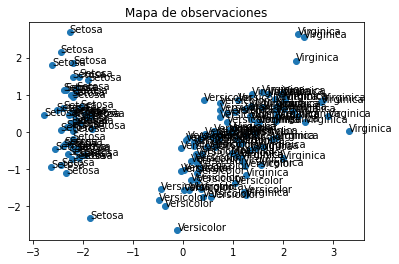

In [11]:
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]
z = df['variety']
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [12]:
componentes_2 = pd.DataFrame(data = modelo_pca.components_,
                             columns = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width'],
                             index = ['PC1', 'PC2', 'PC3', 'PC4'])
componentes_2 = componentes_2.iloc[0:2, :]
componentes_2 = componentes_2.T
componentes_2

,PC1,PC2
sepal.length,0.521066,0.377418
sepal.width,-0.269347,0.923296
petal.length,0.580413,0.024492
petal.width,0.564857,0.066942


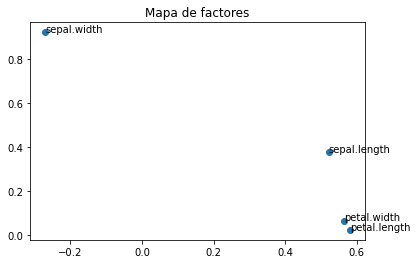

In [13]:
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))